Mean Absolute Error: 42.79
Mean Absolute Error (Ridge Regression): 42.81
R^2 Score (Ridge Regression): 0.45
Mean Absolute Error (Lasso Regression): 42.81
R^2 Score (Lasso Regression): 0.46
Mean Absolute Error (Elastic Net Regression): 42.87
R^2 Score (Elastic Net Regression): 0.46


/var/folders/bp/bf2mwffx73b4f312yvxyns180000gn/T/ipykernel_4963/2594545981.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=mae_values, palette='viridis')


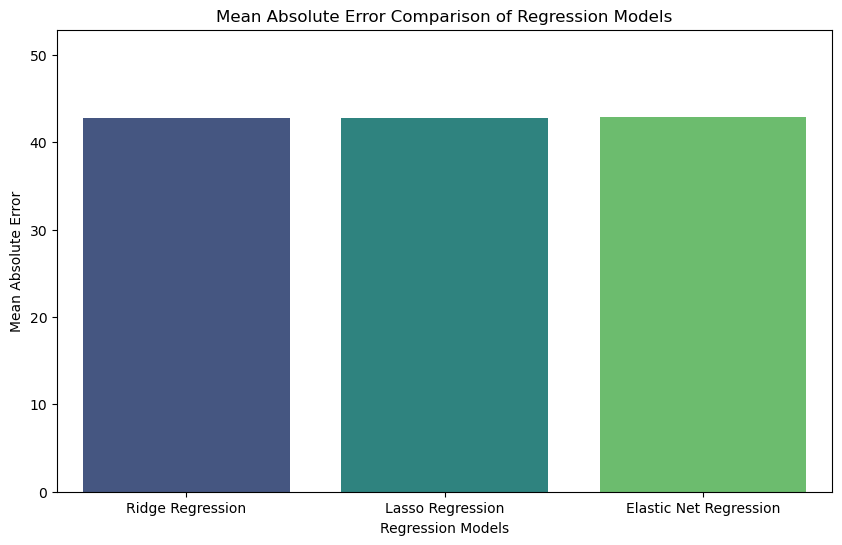

In [ ]:
import sklearn.datasets
import sklearn.linear_model
import sklearn.metrics
import sklearn.model_selection
import sklearn.pipeline
import sklearn.preprocessing
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the diabetes dataset
diabetes = sklearn.datasets.load_diabetes()
X = diabetes.data
y = diabetes.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline that includes standardization and linear regression
pipeline = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.StandardScaler()),
    ('regressor', sklearn.linear_model.LinearRegression())
])

# Fit the model to the training data
pipeline.fit(X_train, y_train) 

# Predict the target values for the test set
y_pred = pipeline.predict(X_test)

# Evaluate the model using Mean Absolute Error
mae = sklearn.metrics.mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae:.2f}')
    
#train the data using Ridge regression
ridge_pipeline = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.StandardScaler()),
    ('regressor', sklearn.linear_model.Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)  
mae_ridge = sklearn.metrics.mean_absolute_error(y_test, y_pred_ridge)
print(f'Mean Absolute Error (Ridge Regression): {mae_ridge:.2f}')

#Get accuracy score for Ridge regression

r2_ridge = sklearn.metrics.r2_score(y_test, y_pred_ridge)
print(f'R^2 Score (Ridge Regression): {r2_ridge:.2f}')  


#train the data using Lasso regression
lasso_pipeline = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.StandardScaler()),
    ('regressor', sklearn.linear_model.Lasso(alpha=0.1))
])

lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)
mae_lasso = sklearn.metrics.mean_absolute_error(y_test, y_pred_lasso)
print(f'Mean Absolute Error (Lasso Regression): {mae_lasso:.2f}')

#Get accuracy score for Lasso regression
r2_lasso = sklearn.metrics.r2_score(y_test, y_pred_lasso)
print(f'R^2 Score (Lasso Regression): {r2_lasso:.2f}') 

#train the data using Elastic Net regression
elastic_net_pipeline = sklearn.pipeline.Pipeline([
    ('scaler', sklearn.preprocessing.StandardScaler()), 
    ('regressor', sklearn.linear_model.ElasticNet(alpha=0.1, l1_ratio=0.5))
])
elastic_net_pipeline.fit(X_train, y_train)
y_pred_elastic_net = elastic_net_pipeline.predict(X_test)
mae_elastic_net = sklearn.metrics.mean_absolute_error(y_test, y_pred_elastic_net)
print(f'Mean Absolute Error (Elastic Net Regression): {mae_elastic_net:.2f}')

#Get accuracy score for Elastic Net regression
r2_elastic_net = sklearn.metrics.r2_score(y_test, y_pred_elastic_net)
print(f'R^2 Score (Elastic Net Regression): {r2_elastic_net:.2f}') 

#create a bar chart to compare the Mean Absolute Error of the three regression models
models = ['Ridge Regression', 'Lasso Regression', 'Elastic Net Regression']
mae_values = [mae_ridge, mae_lasso, mae_elastic_net]
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=mae_values, palette='viridis')
plt.title('Mean Absolute Error Comparison of Regression Models')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Regression Models')
plt.ylim(0, max(mae_values) + 10)
plt.show()
 
